### This is to plot images for the paper to compare the different types of drag

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob as glob
import h5py
import matplotlib.cm as cm
from importlib import import_module
import sys
sys.path.append('../')

In [2]:
plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.serif"] = "Times New Roman"

In [3]:
def sortKeyFunc(s):
    s = s.split('_')[-1] # s{num}.h5
    s = s[1:-3] #num
    return int(s)

def read_dedalus(folder,intype='snapshots'):
    if intype=='snapshots':
        data = []
        ss = sorted(glob.glob(folder+'/'+intype+'/'+intype+'*.h5'),key=sortKeyFunc)
        for file in ss:
            data.append(h5py.File(file,'r'))
    elif intype=='time_series':
        data = dict([])
        ss = sorted(glob.glob(folder+'/'+intype+'/'+intype+'*.h5'),key=sortKeyFunc)
        for ii,file in enumerate(ss):
            if ii==0:
                data['time'] = h5py.File(file,'r')['scales']['sim_time']
                data['timestep'] = h5py.File(file,'r')['scales']['iteration']
            else:
                data['time'] = np.hstack((data['time'],h5py.File(file,'r')['scales']['sim_time']))
                data['timestep'] = h5py.File(file,'r')['scales']['iteration']

        temp = h5py.File(ss[0],'r')
        tasks = list(temp['tasks'].keys())
        for task in tasks:
            for ii,file in enumerate(ss):
                if ii==0:
                    data[task] = h5py.File(file,'r')['tasks'][task][:,0]
                else:
                    data[task] = np.hstack((data[task],h5py.File(file,'r')['tasks'][task][:,0]))
        data['len_ss'] = len(ss)
    return data

def snapshot_slice(n,data,field):
    for ii,subdat in enumerate(data):
        if np.any(subdat['scales']['write_number'][:]==n):
            n_m = np.squeeze(np.where(subdat['scales']['write_number'][:]==n))
            s = ii
    return [s,n_m]

In [4]:
a_exp = 0.0
c1_exp = -1.0

# Calibrated using single band MWF mean, a_exp = 0, eps_exp = -1, nu_t_exp = 1.0 (Re_c = 72)
def nu_t(qe,C_t,Re):
    return C_t*qe*Re**(-c1_exp) + 1/Re
    
C_t = 0.05
a = 0.3
c1 = 0.144
b = 0.0

kappa = 0.045
kexp = 0.0
eta = 5e-3

alpha = 0.01
beta = np.pi/2

In [5]:
## Calibrated by MWF (newuq)
def A(q,a,eta,Re):
    return a*(Re/67)**(a_exp)*((q**2 + eta**2)**(1/2) - eta)

def B(q,b):
    return b*q

def eps(q,c1,Re):
    return c1*(Re/67)**(c1_exp)*q

def dA(qe,a,eta,Re):
    return a*(Re/67)**(a_exp)*qe*(qe**2 + eta**2)**(-1/2)

def dB(b):
    return b

def deps(qe,c1,Re):
    return c1*(Re/67)**(c1_exp)

In [6]:
# Define nullclines (for plotting)
def null_u(q,beta,eta,a,alpha,Re):
    return -beta*A(q,a,eta,Re)/(alpha+beta**2/Re) + 1 # u nullcline
def null_q(q,beta,eta,a,c1,alpha,Re): 
    return (2*alpha*q + eps(q,c1,Re))/(beta*A(q,a,eta,Re)/2)

In [7]:
c = c1*67
A_eq = lambda q0 : a*(np.sqrt(q0**2+eta**2)-eta)

def nul(q0,Re):
    return beta*A_eq(q0)*(alpha+beta**2/Re-beta*A_eq(q0))/2-(2*alpha+c/Re)*(alpha+beta**2/Re)*q0

## Loading Data - loads all data from diff files

In [8]:
# Choose input directory
idir = './'

# Choose output directory
odir = './Paper Figures/'

In [9]:
# Re 64

# Searches through all directories in 'Data' folder (which are named after experiments) and imports the data:dirs64
dirs64 = sorted(glob.glob(idir+'Lz256_Re64_IC68_minimal_v3d5'))

runs64 = []
Res64 = []
for file in dirs64:
    run = file.split('/')[1]

    Re = run.split('_')[1].replace('d','.')[2:]
    Res64.append(float(Re))
    runs64.append(run)
    
Res64 = np.array(Res64)
runs64 = np.array(runs64)
argRes64 = Res64.argsort()
Res64 = Res64[argRes64]
runs64 = runs64[argRes64]
Res64 = np.unique(Res64)

data64 = dict([])
for run in runs64:
    data64[run] = read_dedalus(idir+run)

print(runs64)
print(Res64)

['Lz256_Re64_IC68_minimal_v3d5']
[64.]


In [10]:
#Re 66

# Searches through all directories in 'Data' folder (which are named after experiments) and imports the data:
dirs66 = sorted(glob.glob(idir+'Lz256_Re66_IC68_minimal_v3d5'))

runs66 = []
Res66 = []
for file in dirs66:
    run = file.split('/')[1]

    Re = run.split('_')[1].replace('d','.')[2:]
    Res66.append(float(Re))
    runs66.append(run)
    
Res66 = np.array(Res66)
runs66 = np.array(runs66)
argRes66 = Res66.argsort()
Res66 = Res66[argRes66]
runs66 = runs66[argRes66]
Res66 = np.unique(Res66)

data66 = dict([])
for run in runs66:
    data66[run] = read_dedalus(idir+run)

print(runs66)
print(Res66)

['Lz256_Re66_IC68_minimal_v3d5']
[66.]


In [11]:
#Re 80

# Searches through all directories in 'Data' folder (which are named after experiments) and imports the data:
dirs80 = sorted(glob.glob(idir+'Lz256_Re80_IC68_minimal_v3d5'))

runs80 = []
Res80 = []
for file in dirs80:
    run = file.split('/')[1]

    Re = run.split('_')[1].replace('d','.')[2:]
    Res80.append(float(Re))
    runs80.append(run)
    
Res80 = np.array(Res80)
runs80 = np.array(runs80)
argRes80 = Res80.argsort()
Res80 = Res80[argRes80]
runs80 = runs80[argRes80]
Res80 = np.unique(Res80)

data80 = dict([])
for run in runs80:
    data80[run] = read_dedalus(idir+run)

print(runs80)
print(Res80)

['Lz256_Re80_IC68_minimal_v3d5']
[80.]


In [12]:
#Re 82

# Searches through all directories in 'Data' folder (which are named after experiments) and imports the data:
dirs82 = sorted(glob.glob(idir+'Lz256_Re82_IC68_minimal_v3d5'))

runs82 = []
Res82 = []
for file in dirs82:
    run = file.split('/')[1]

    Re = run.split('_')[1].replace('d','.')[2:]
    Res82.append(float(Re))
    runs82.append(run)
    
Res82 = np.array(Res82)
runs82 = np.array(runs82)
argRes82 = Res82.argsort()
Res82 = Res82[argRes82]
runs82 = runs82[argRes82]
Res82 = np.unique(Res82)

data82 = dict([])
for run in runs82:
    data82[run] = read_dedalus(idir+run)

print(runs82)
print(Res82)

['Lz256_Re82_IC68_minimal_v3d5']
[82.]


In [14]:
# Re 90

# Searches through all directories in 'Data' folder (which are named after experiments) and imports the data:
dirs90 = sorted(glob.glob(idir+'Lz256_Re90_IC68_minimal_v3d5'))

runs90 = []
Res90 = []
for file in dirs90:
    run = file.split('/')[1]

    Re = run.split('_')[1].replace('d','.')[2:]
    Res90.append(float(Re))
    runs90.append(run)
    
Res90 = np.array(Res90)
runs90 = np.array(runs90)
argRes90 = Res90.argsort()
Res90 = Res90[argRes90]
runs90 = runs90[argRes90]
Res90 = np.unique(Res90)

data90 = dict([])
for run in runs90:
    data90[run] = read_dedalus(idir+run)

print(runs90)
print(Res90)

['Lz256_Re90_IC68_minimal_v3d5']
[90.]


In [16]:
# for run in runs64:
#     print(run)
#     print(data[run])
#     for subdat in data[run]:
#         print(subdat['scales'].keys())
#         print(subdat['tasks'].keys())
# #         print(subdat['scales']['sim_time'][:])

In [17]:
all_runs = [runs64, runs66, runs80, runs82, runs90] 
all_Res = [64, 66, 80, 82, 90]

all_data = [data64, data66, data80, data82, data90]

print (all_Res)


[64, 66, 80, 82, 90]


## $u_0$ vs $q_0$ plotting

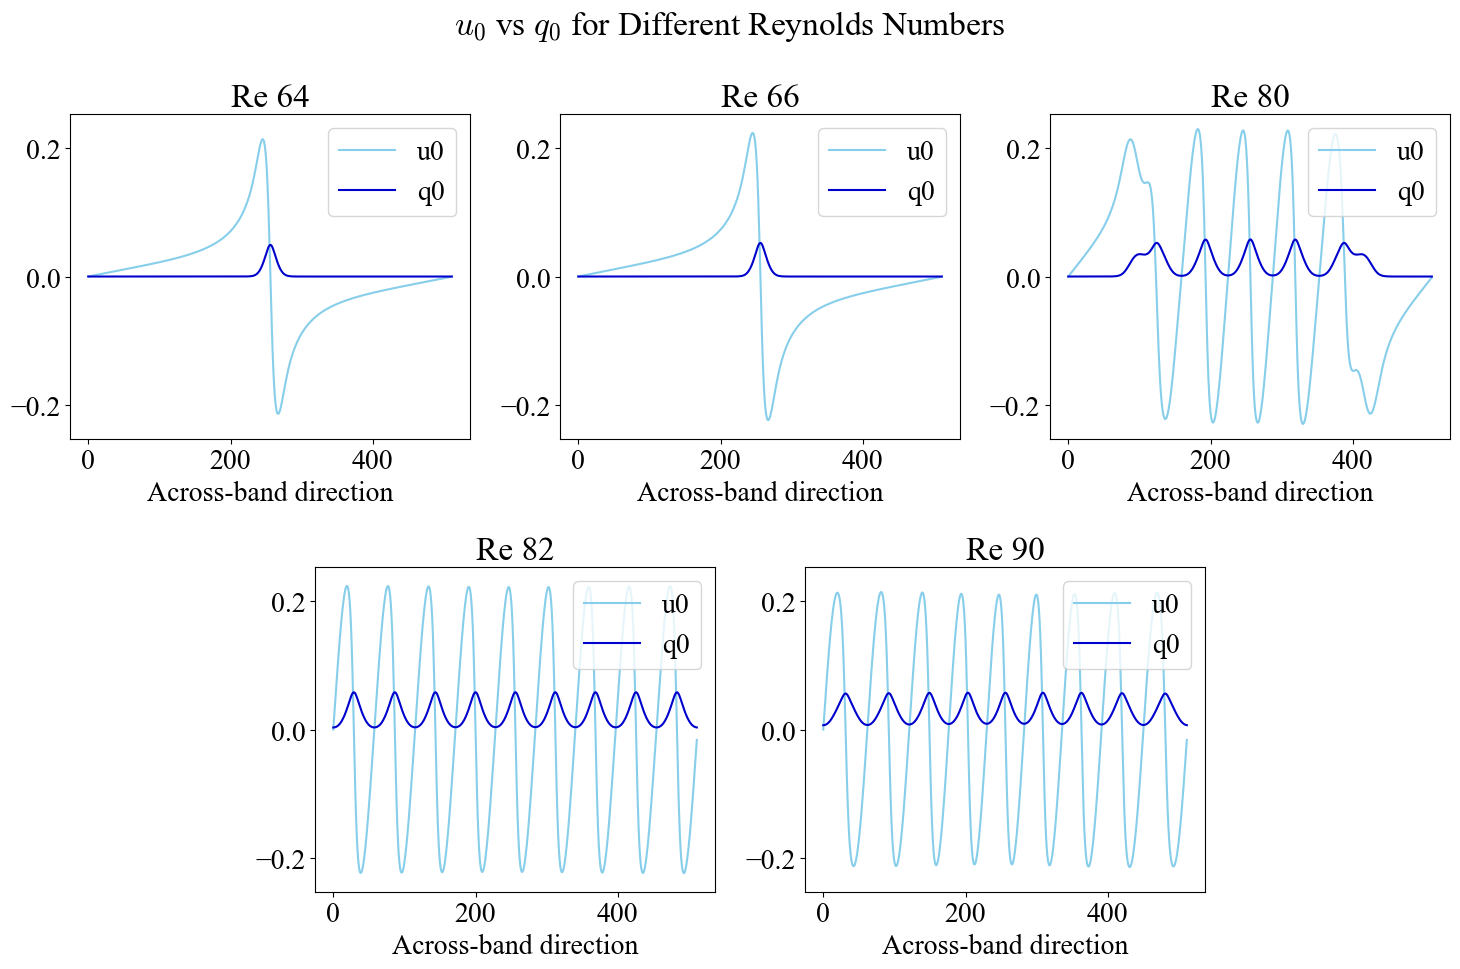

In [38]:
fig = plt.figure(figsize=(15,10))
ax1 = plt.subplot2grid((4, 6), (0, 0), colspan=2, rowspan=2)
ax2 = plt.subplot2grid((4, 6), (0, 2), colspan=2, rowspan=2, sharey=ax1)
ax3 = plt.subplot2grid((4, 6), (0, 4), colspan=2, rowspan=2, sharey=ax1)
ax4 = plt.subplot2grid((4, 6), (2, 1), colspan=2, rowspan=2, sharey=ax1)
ax5 = plt.subplot2grid((4, 6), (2, 3), colspan=2, rowspan=2, sharey=ax1)

for i, ax in enumerate(fig.axes): 
    runs = all_runs[i]
    data = all_data[i]
    Re = all_Res[i]
    for run in runs:
        ax.plot((data[run][0]['tasks']['u0'][()])[-1], 'skyblue' ,label = 'u0')
        ax.plot((data[run][0]['tasks']['q0'][()])[-1], 'mediumblue', label = 'q0')
        ax.set_title(f'Re {Re}')
        ax.set_xlabel ('Across-band direction')
        ax.legend (loc = 'upper right')


fig.suptitle(f'$u_0$ vs $q_0$ for Different Reynolds Numbers')
fig.savefig(odir+'All_u0_vs_q0.png',dpi=150,bbox_inches='tight')
fig.tight_layout()


plt.show()


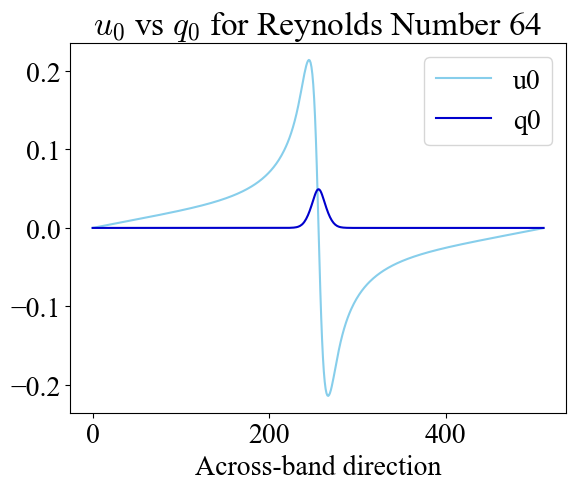

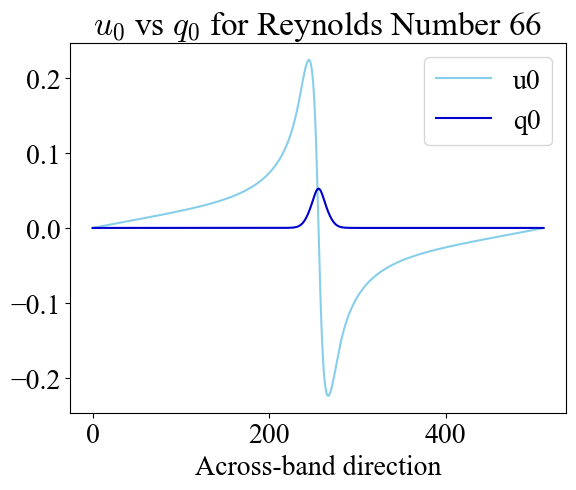

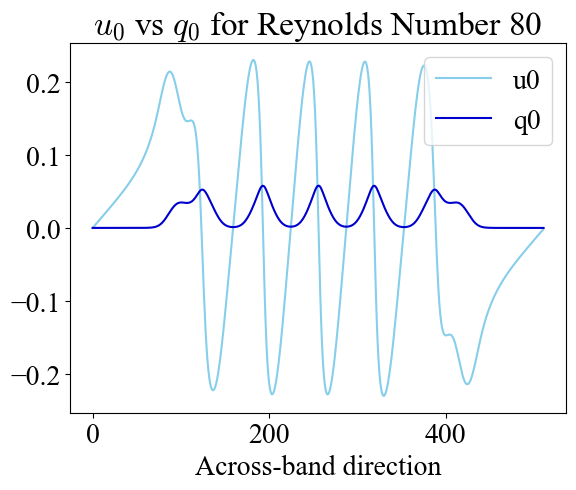

In [39]:
for i in range(3): 
    runs = all_runs[i]
    data = all_data[i]
    Re = all_Res[i]
    for run in runs:
        plt.plot((data[run][0]['tasks']['u0'][()])[-1],'skyblue', label = 'u0')
        plt.plot((data[run][0]['tasks']['q0'][()])[-1], 'mediumblue', label = 'q0')
        plt.title(f'$u_0$ vs $q_0$ for Reynolds Number {Re}')
        plt.xlabel('Across-band direction')
        plt.legend (loc= 'upper right')
        plt.savefig(odir+f'Re{Re}_u0_vs_q0.png',dpi=150,bbox_inches='tight')
        plt.show()


## Spacetime Plots

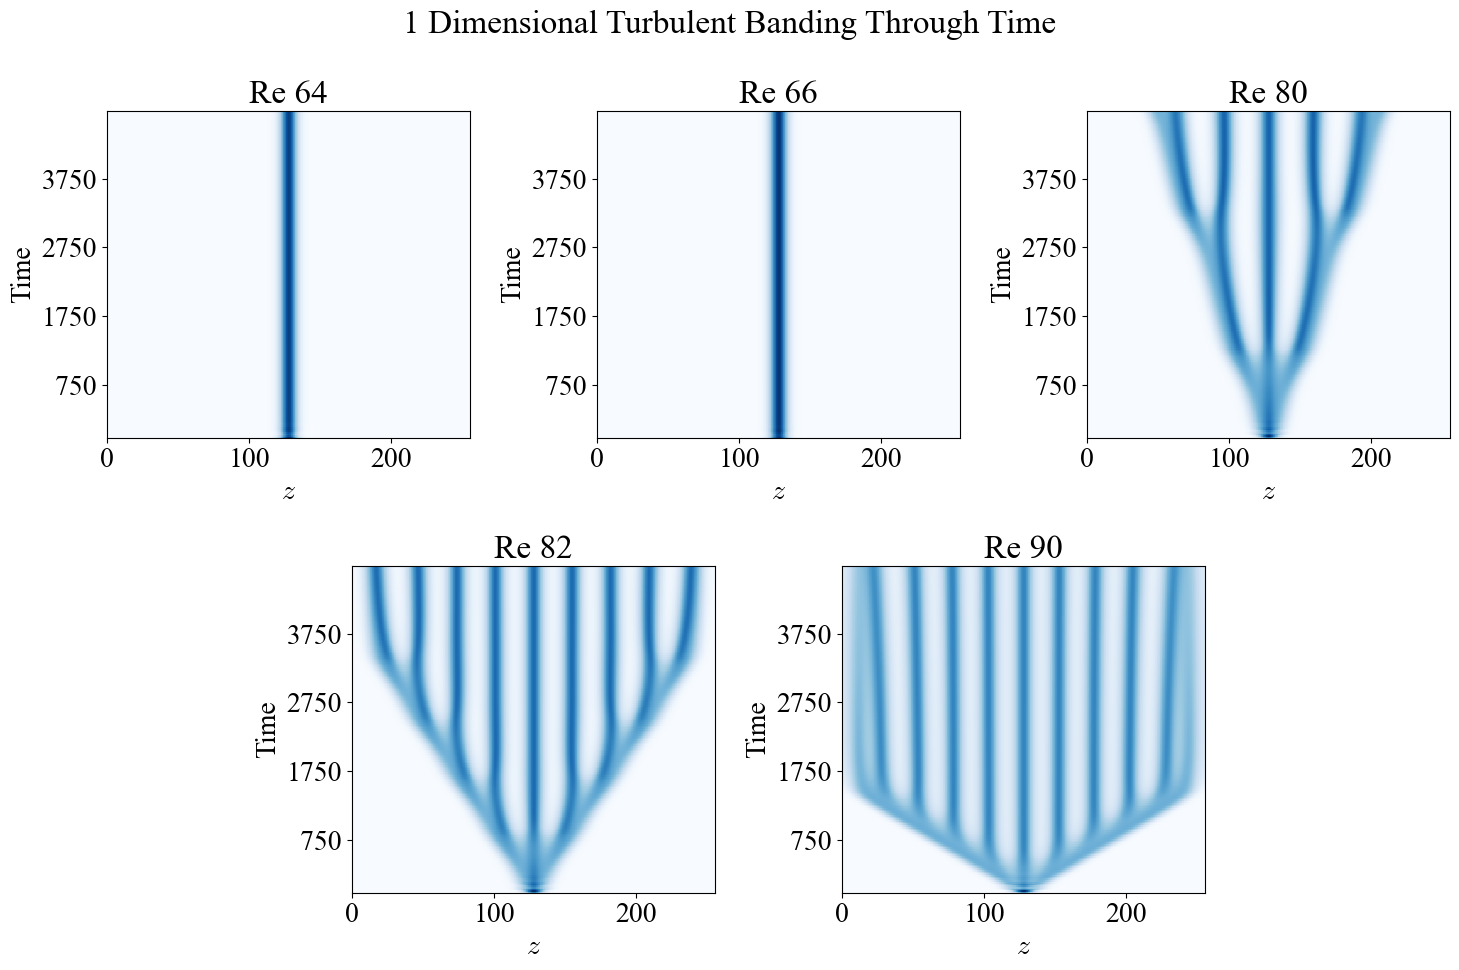

In [47]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

# full_cmap = cm.bwr_r
# half_cmap = LinearSegmentedColormap.from_list('half_bone', full_cmap(np.linspace(0.5, 1, 128)))


fig = plt.figure(figsize=(15,10))
ax1 = plt.subplot2grid((4, 6), (0, 0), colspan=2, rowspan=2)
ax2 = plt.subplot2grid((4, 6), (0, 2), colspan=2, rowspan=2)
ax3 = plt.subplot2grid((4, 6), (0, 4), colspan=2, rowspan=2)
ax4 = plt.subplot2grid((4, 6), (2, 1), colspan=2, rowspan=2)
ax5 = plt.subplot2grid((4, 6), (2, 3), colspan=2, rowspan=2)

for i, ax in enumerate(fig.axes):
    runs = all_runs[i]
    data = all_data[i]
    Re = all_Res[i]

    for run in runs[:]:
        try:
            for ii, subdat in enumerate(data[run]):
                if ii == 0:
                    t = subdat['scales']['sim_time'][:]
                    z = subdat['scales']['z']['1.0'][:]
                    Lz = np.max(z)
                    try:
                        dat = subdat['tasks']['q0'][:]
                    except:
                        dat = subdat['tasks']['q'][:]
                else:
                    t = np.concatenate((t, subdat['scales']['sim_time'][:]))
                    try:
                        dat = np.concatenate((dat, subdat['tasks']['q0'][:]))
                    except:
                        dat = np.concatenate((dat, subdat['tasks']['q'][:]))

            T, X = np.meshgrid(t, z, indexing='ij')

            # print('min', np.min(dat), np.where(dat[:] < -1e-6))

            pcm = ax.pcolormesh(X, T, dat[:], vmin=0, vmax=np.max(dat[t > 50]), cmap=cm.Blues)
            # fig.colorbar(pcm, ax=ax)   

            ax.set_xlabel(r"$z$", fontsize=20)
            ax.set_ylabel(r"Time", fontsize=20) 

            # # ax.set_ylim(top= 20000)
            # yticks = ax.get_yticks()
            # ax.set_yticks(yticks)
            # ax.set_yticklabels([f'{int(y - yticks[0])}' for y in yticks])
            # ax.autoscale(axis='y', tight=True)
            # ax.autoscale(axis='y', tight=True)

            # ax.set_ylim(bottom=15229, top=19979)
            # yticks = ax.get_yticks()
            # ax.set_yticks(yticks)
            # ax.set_yticklabels([f'{int(y - 15229)}' for y in yticks])

            ax.set_ylim(bottom=15229, top=19979)
            yticks = [t for t in ax.get_yticks() if 15229 <= t <= 19979]
            ax.set_yticks(yticks)
            ax.set_yticklabels([f'{int(y - 15250)}' for y in yticks])
        
            ax.set_title(f'Re {Re}')                   

        except ():
            print('hey')
            

fig.suptitle ('1 Dimensional Turbulent Banding Through Time')
fig.tight_layout()

plt.savefig(odir + 'All turbulence.png', dpi=150, bbox_inches='tight')
plt.show()

min -8.468255300613414e-16 (array([], dtype=int64), array([], dtype=int64))


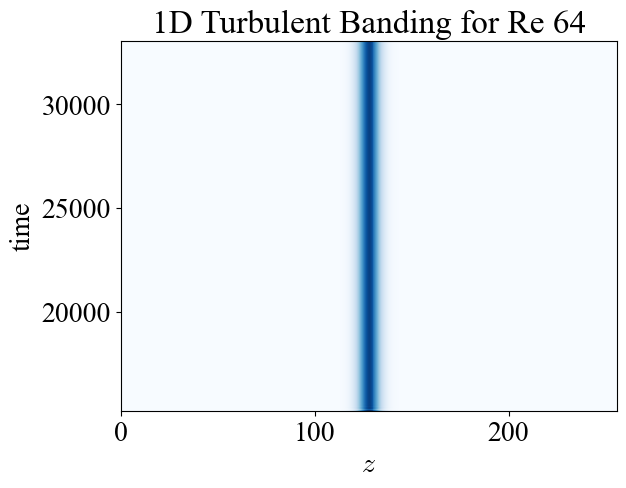

min -2.2724877535296173e-15 (array([], dtype=int64), array([], dtype=int64))


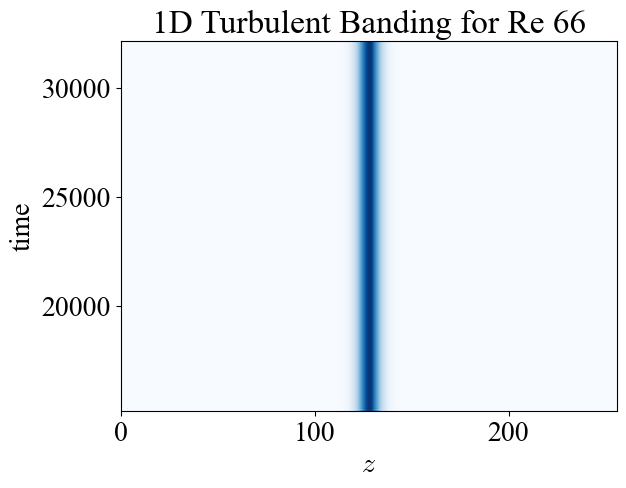

min -2.6548294812522855e-13 (array([], dtype=int64), array([], dtype=int64))


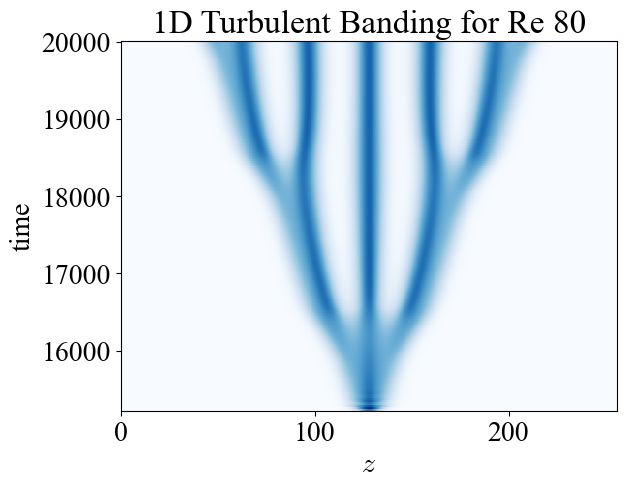

min -4.25847941978863e-13 (array([], dtype=int64), array([], dtype=int64))


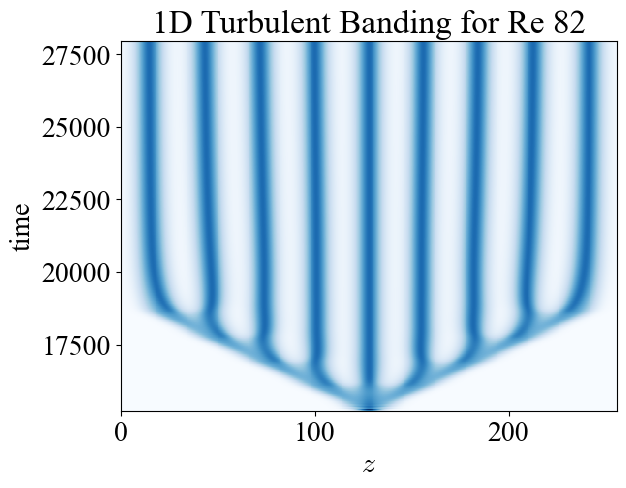

min -1.9544210000388418e-12 (array([], dtype=int64), array([], dtype=int64))


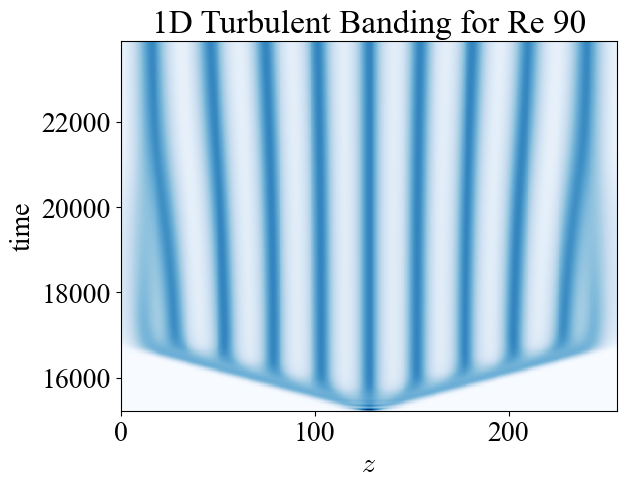

In [48]:

for i in range (5): 
    runs = all_runs[i]
    data = all_data[i]
    Re = all_Res[i]
    for run in runs[:]: 
    #     if '85' in run:
        try:
            for ii,subdat in enumerate(data[run]):
                if ii==0:
                    t = subdat['scales']['sim_time'][:]
                    z = subdat['scales']['z']['1.0'][:]
                    Lz = np.max(z)
                    try:
                        dat = subdat['tasks']['q0'][:]
                    except:
                        dat = subdat['tasks']['q'][:]
                else:
                    t = np.concatenate((t,subdat['scales']['sim_time'][:]))
                    try:
                        dat = np.concatenate((dat,subdat['tasks']['q0'][:]))
                    except:
                        dat = np.concatenate((dat,subdat['tasks']['q'][:]))
            T,X = np.meshgrid(t,z,indexing='ij')
        #     T,X = np.meshgrid(np.arange(len(t[:])),z,indexing='ij')
            print('min',np.min(dat),np.where(dat[:]<-1e-6))
        #     plt.contourf(X,T,dat[:],vmin=0,vmax=np.max(dat[:]),cmap= cm.copper)
            plt.pcolormesh(X,T,dat[:],vmin=0,vmax=np.max(dat[t>50]),cmap= cm.Blues)
            plt.xlabel(r"$z$",fontsize=20)
    #         plt.ylim(0,400)
            plt.ylabel(r"time",fontsize=20)

    #         xplt = np.linspace(128,256,1000)
    #         v = 1/0.07#0.065
    #         plt.plot(xplt,200+v*(xplt-130))

        #     plt.ylabel(r"output number",fontsize=20)
            plt.title(f'1D Turbulent Banding for Re {Re}') 
            plt.savefig(odir+f'turbulence_{Re}.png',dpi=150,bbox_inches='tight')
            plt.show()
        except():
            print('hey')